In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import randint, uniform, loguniform

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
import subprocess
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.inspection import permutation_importance

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df_ml = pd.read_csv('../data/cleaned_train_listing_ml.csv')
df_test = pd.read_csv('../data/cleaned_test_listing_ml.csv')
df_ml_no_influential = pd.read_csv('../data/influential_cleaned_train_listing_ml.csv')


In [3]:
df_ml_no_influential.columns

Index(['host_is_superhost', 'neighbourhood_cleansed', 'latitude', 'longitude',
       'property_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'price', 'minimum_nights', 'price_log', 'availability_365',
       'instant_bookable', 'room_type_Entire home/apt', 'room_type_Hotel room',
       'room_type_Private room', 'room_type_Shared room',
       'neighbourhood_group_cleansed_City of Los Angeles',
       'neighbourhood_group_cleansed_Other Cities',
       'neighbourhood_group_cleansed_Unincorporated Areas', 'cooks_d'],
      dtype='object')

In [4]:
df_ml.columns

Index(['host_is_superhost', 'neighbourhood_cleansed', 'latitude', 'longitude',
       'property_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'price', 'minimum_nights', 'price_log', 'availability_365',
       'instant_bookable', 'room_type_Entire home/apt', 'room_type_Hotel room',
       'room_type_Private room', 'room_type_Shared room',
       'neighbourhood_group_cleansed_City of Los Angeles',
       'neighbourhood_group_cleansed_Other Cities',
       'neighbourhood_group_cleansed_Unincorporated Areas'],
      dtype='object')

In [6]:
df_ml.dtypes

host_is_superhost                                      int64
neighbourhood_cleansed                                 int64
latitude                                             float64
longitude                                            float64
property_type                                          int64
accommodates                                           int64
bathrooms                                            float64
bedrooms                                             float64
beds                                                 float64
price                                                float64
minimum_nights                                         int64
price_log                                            float64
availability_365                                       int64
instant_bookable                                       int64
room_type_Entire home/apt                               bool
room_type_Hotel room                                    bool
room_type_Private room  

In [5]:
X_train_no_influential = df_ml_no_influential.drop(columns=[ "price", "price_log", "cooks_d"])
y_train_no_influential = df_ml_no_influential["price"]
y_log_train_no_influential = df_ml_no_influential["price_log"]

X_train = df_ml.drop(columns=[ "price", "price_log"])
y_train = df_ml["price"]
y_log_train = df_ml["price_log"]

X_test = df_test.drop(columns=[ "price", "price_log", "price_per_night"])
y_test = df_test["price"]
y_log_test = df_test["price_log"]

In [6]:
# ============================================
# Models
# ============================================

models = {
    "linear Regressor": LinearRegression(),
    "Support Vector Regressor": SVR(kernel="rbf"),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    # "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        random_state=42
    )
}


# ============================================
# Stacking Model
# ============================================

base_learners = [
    ("Random Forest", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )),
    ("SVR", SVR(kernel="rbf")),
    ("XGBoost", XGBRegressor(
        n_estimators=100,
        random_state=42
    ))
]

meta_model = LinearRegression()

stacking_regressor = StackingRegressor(
    estimators=base_learners,
    final_estimator=meta_model
)

# ============================================
# Evaluation Function (Original Price)
# ============================================

def evaluate_model_price(model, X_train, y_train, X_test, y_test):

    # Train the model
    model.fit(X_train, y_train)

    # Predict on log scale
    y_train_pred_log = model.predict(X_train)
    y_test_pred_log = model.predict(X_test)

    # Convert actual values back to original price
    y_train_actual = np.expm1(y_train)
    y_test_actual = np.expm1(y_test)

    # Convert predictions back to original price
    y_train_pred = np.expm1(y_train_pred_log)
    y_test_pred = np.expm1(y_test_pred_log)

    # Calculate R²
    train_r2 = r2_score(y_train_actual, y_train_pred)
    test_r2 = r2_score(y_test_actual, y_test_pred)

    return {
        "Train MAE": mean_absolute_error(y_train_actual, y_train_pred),
        "Test MAE": mean_absolute_error(y_test_actual, y_test_pred),

        "Train MSE": mean_squared_error(y_train_actual, y_train_pred),
        "Test MSE": mean_squared_error(y_test_actual, y_test_pred),

        "Train RMSE": np.sqrt(mean_squared_error(y_train_actual, y_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test_actual, y_test_pred)),

        "Train R²": train_r2,
        "Test R²": test_r2,

        "R² Gap": train_r2 - test_r2
    }

In [7]:
# ============================================
# Evaluate Individual Models
# ============================================

results = []

for name, model in models.items():

    print(f"Evaluating {name}...")

    metrics = evaluate_model_price(
        model,
        X_train_no_influential,
        y_log_train_no_influential,
        X_test,
        y_log_test
    )

    metrics["Model"] = name

    results.append(metrics)

# ============================================
# Evaluate Stacking Regressor
# ============================================

print("Evaluating Stacking Regressor...")

stack_metrics = evaluate_model_price(
    stacking_regressor,
    X_train_no_influential,
    y_log_train_no_influential,
    X_test,
    y_log_test
)

stack_metrics["Model"] = "Stacking Regressor"

results.append(stack_metrics)

# ============================================
# Results Table
# ============================================

performance_df = pd.DataFrame(results)

performance_df = performance_df[
    [
        "Model",

        "Train MAE",
        "Test MAE",

        "Train MSE",
        "Test MSE",
        
        "Train RMSE",
        "Test RMSE",
        
        "Train R²",
        "Test R²",

        "R² Gap"
    ]
]

performance_df = performance_df.sort_values(
    by="Test R²",
    ascending=False
)

performance_df = performance_df.round(4)

print("\n========== Regression Model Performance ==========\n")
performance_df


Evaluating linear Regressor...
Evaluating Support Vector Regressor...
Evaluating Random Forest...
Evaluating XGBoost...
Evaluating Stacking Regressor...

========== Regression Model Performance ==========



,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R²,Test R²,R² Gap
0,linear Regressor,86.1406,130.6633,34221.7889,251263.4924,184.9913,501.2619,0.5260,0.4027,0.1234
3,XGBoost,50.6334,107.8967,11190.5164,255306.0715,105.7852,505.2782,0.8450,0.3931,0.4520
4,Stacking Regressor,36.8228,105.6020,6724.0215,255932.5292,82.0001,505.8977,0.9069,0.3916,0.5153
2,Random Forest,25.2713,107.6899,3883.9819,261667.7564,62.3216,511.5347,0.9462,0.3779,0.5683
1,Support Vector Regressor,101.4029,155.5033,49964.9718,367171.0048,223.5285,605.9464,0.3080,0.1271,0.1809


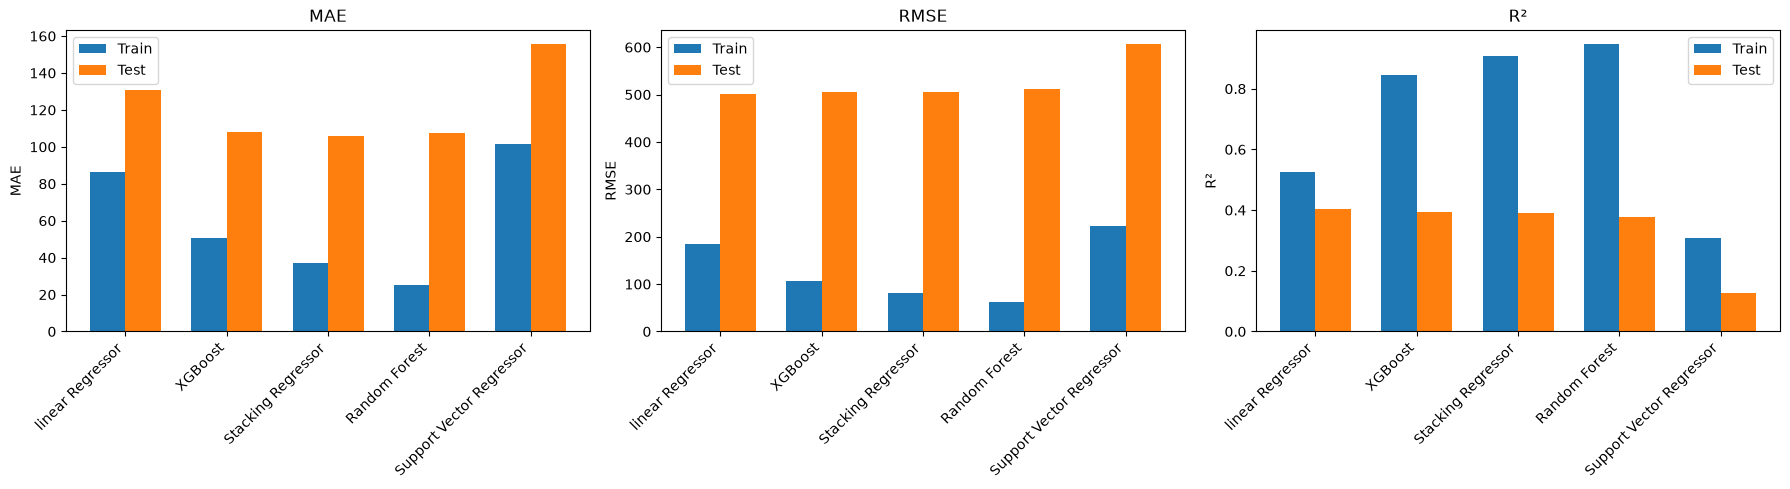

In [8]:

metrics = ["MAE", "RMSE", "R²"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(performance_df))
width = 0.35

for ax, metric in zip(axes, metrics):

    train_values = performance_df[f"Train {metric}"]
    test_values = performance_df[f"Test {metric}"]

    ax.bar(x - width/2, train_values, width, label="Train")
    ax.bar(x + width/2, test_values, width, label="Test")

    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(performance_df["Model"], rotation=45, ha="right")
    ax.set_ylabel(metric)
    ax.legend()

plt.tight_layout()
plt.show()

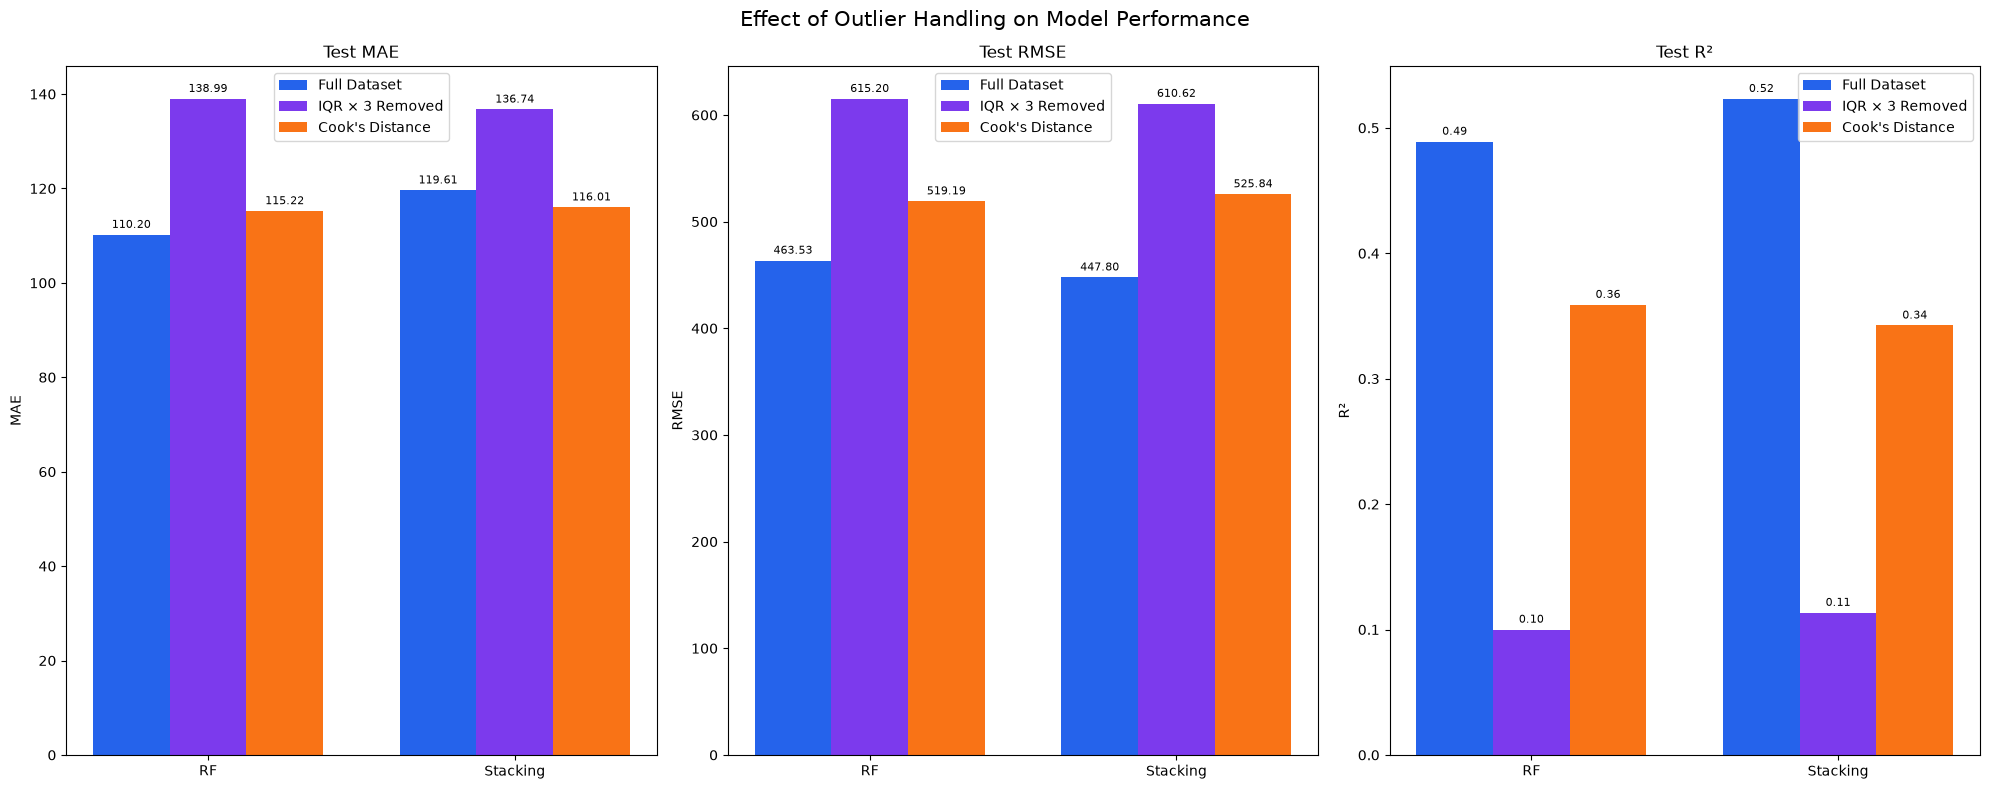

In [9]:

# ============================================================
# Results
# ============================================================

results = {

    "Full Dataset": {
        "RF": {
            "MAE": 110.1967,
            "RMSE": 463.5266,
            "R²": 0.4891
        },
        "Stacking": {
            "MAE": 119.6105,
            "RMSE": 447.7985,
            "R²": 0.5232
        }
    },

    "IQR × 3 Removed": {
        "RF": {
            "MAE": 138.9912,
            "RMSE": 615.1954,
            "R²": 0.1000
        },
        "Stacking": {
            "MAE": 136.7364,
            "RMSE": 610.6169,
            "R²": 0.1134
        }
    },


    "Cook's Distance": {
        "RF": {
            "MAE": 115.2160,
            "RMSE": 519.1933,
            "R²": 0.3590
        },
        "Stacking": {
            "MAE": 116.0104,
            "RMSE": 525.8356,
            "R²": 0.3425
        }
    }
}


# ============================================================
# Plot
# ============================================================

models = ["RF", "Stacking"]
datasets = [
    "Full Dataset",
    "IQR × 3 Removed",
    "Cook's Distance"
]

metrics = ["MAE", "RMSE", "R²"]

x = np.arange(len(models))

# Three datasets → three bars per model
width = 0.25

fig, axes = plt.subplots(
    1, 3,
    figsize=(20, 8)
)

# Dataset colors
dataset_colors = {
    "Full Dataset": "#2563EB",
    "IQR × 3 Removed": "#7C3AED",
    "Cook's Distance": "#F97316"
}

for ax, metric in zip(axes, metrics):

    for i, dataset in enumerate(datasets):

        values = [
            results[dataset][model][metric]
            for model in models
        ]

        offset = (i - 1) * width

        bars = ax.bar(
            x + offset,
            values,
            width,
            label=dataset,
            color=dataset_colors[dataset]
        )

        # Add values
        ax.bar_label(
            bars,
            fmt="%.2f",
            padding=3,
            fontsize=8
        )

    ax.set_title(f"Test {metric}")
    ax.set_ylabel(metric)

    ax.set_xticks(x)
    ax.set_xticklabels(models)

    ax.legend()


# ============================================================
# Overall title
# ============================================================

plt.suptitle(
    "Effect of Outlier Handling on Model Performance",
    fontsize=15
)

plt.tight_layout()
plt.show()

Although the removal of influential observations improved predictive performance, several influential observations represented legitimate high-priced listings. Therefore, removing them may improve aggregate model performance at the cost of reducing representation of the high-end Airbnb market.

## Hyperparameter Tuning

In [10]:
print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)

Mon Aug 17 13:32:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.29                 Driver Version: 581.29         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   39C    P8            N/A  /  115W |    1485MiB /   8188MiB |      9%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Random Forest Model

In [11]:

# # ============================================
# # Random Forest Model
# # ============================================

# rf = RandomForestRegressor(
#     random_state=42,
#     n_jobs=-1
# )

# # ============================================
# # Hyperparameter Search Space
# # ============================================

# param_dist = {
#     "n_estimators": randint(100, 500),
#     "max_depth": [None, 10, 15, 20, 25, 30],
#     "min_samples_split": randint(2, 10),
#     "min_samples_leaf": randint(1, 5),
#     "max_features": ["sqrt", "log2", 0.5, 0.7, 1.0]
# }

# # ============================================
# # Random Search
# # ============================================

# random_search_rf = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_dist,
#     n_iter=15,
#     scoring="neg_mean_absolute_error",
#     cv=3,
#     random_state=42,
#     verbose=2,
#     n_jobs=-1,
#     refit=True
# )

# # ============================================
# # Train on LOG target
# # ============================================

# random_search_rf.fit(
#     X_train,
#     y_log_train
# )

# # ============================================
# # Results
# # ============================================

# print("\nBest Parameters:")
# print(random_search_rf.best_params_)

# print("\nBest Cross Validation MAE:")
# print(round(-random_search_rf.best_score_, 4))

# best_rf = random_search_rf.best_estimator_

In [12]:
# y_pred_log_train = best_rf.predict(X_train)

# # Convert predictions back to original price scale
# y_pred_train = np.expm1(y_pred_log_train)


# # Evaluate on original price scale
# print("MAE :", mean_absolute_error(y_train, y_pred_train))
# print("MSE :", mean_squared_error(y_train, y_pred_train))
# print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
# print("R²  :", r2_score(y_train, y_pred_train))

In [13]:
# y_pred_log_test = best_rf.predict(X_test)

# # Convert predictions back to original price scale
# y_pred_test = np.expm1(y_pred_log_test)

# # Evaluate on original price scale
# print("MAE :", mean_absolute_error(y_test, y_pred_test))
# print("MSE :", mean_squared_error(y_test, y_pred_test))
# print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
# print("R²  :", r2_score(y_test, y_pred_test))

### Stacking Regressor Model

In [14]:
# ============================================
# Stacking
# ============================================
# ============================================
# Base Learners
# ============================================
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(kernel="rbf"))
])

base_learners = [
    ("rf", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )),

    ("svr", svr_pipeline),

    ("xgb", XGBRegressor(
        objective="reg:squarederror",
        n_estimators=100,
        random_state=42,
        tree_method="hist",
        device="cuda"
    ))
]

# ============================================
# Meta Model
# ============================================

meta_model = LinearRegression()


# ============================================
# Stacking Model
# ============================================

stacking_regressor = StackingRegressor(
    estimators=base_learners,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)


# ============================================
# Hyperparameter Search Space
# ============================================
param_dist = {

    # -------------------------
    # Random Forest
    # -------------------------
    "rf__n_estimators": randint(100, 500),
    "rf__max_depth": [None, 10, 15, 20, 25, 30],
    "rf__min_samples_split": randint(2, 10),
    "rf__min_samples_leaf": randint(1, 5),
    "rf__max_features": ["sqrt", "log2", 0.5, 0.7, 1.0],

    # ============================================
    # SVR
    # ============================================
    
    "svr__svr__C": loguniform(0.1, 100),
    "svr__svr__gamma": [
        "scale",
        "auto"
    ],
    "svr__svr__epsilon": uniform(0.01, 0.5),

    # -------------------------
    # XGBoost
    # -------------------------
    "xgb__n_estimators": randint(100, 600),
    "xgb__max_depth": randint(3, 12),
    "xgb__learning_rate": loguniform(0.01, 0.2),
    "xgb__subsample": uniform(0.7, 0.3),
    "xgb__colsample_bytree": uniform(0.5, 0.5),
    "xgb__min_child_weight": randint(1, 10),
    "xgb__gamma": uniform(0, 0.5),
    "xgb__reg_alpha": loguniform(1e-3, 10),
    "xgb__reg_lambda": loguniform(0.1, 10),
}


# ============================================
# Randomized Search
# ============================================

random_search = RandomizedSearchCV(
    estimator=stacking_regressor,
    param_distributions=param_dist,

    n_iter=20,

    scoring="neg_mean_absolute_error",

    cv=3,

    random_state=42,

    verbose=2,

    n_jobs=1,

    refit=True
)


# ============================================
# Train
# ============================================

random_search.fit(X_train, y_log_train)


# ============================================
# Results
# ============================================

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Cross Validation MAE:")
print(-random_search.best_score_)


# Best Stacking Model
best_stacking = random_search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits


C:\Users\YapJack\anaconda3\envs\fyp\Lib\site-packages\xgboost\core.py:553: UserWarning: [13:33:11] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END rf__max_depth=20, rf__max_features=1.0, rf__min_samples_leaf=3, rf__min_samples_split=4, rf__n_estimators=171, svr__svr__C=6.2513735745217485, svr__svr__epsilon=0.08800932022121825, svr__svr__gamma=scale, xgb__colsample_bytree=0.5499874579090014, xgb__gamma=0.22962444598293358, xgb__learning_rate=0.0271747096730583, xgb__max_depth=10, xgb__min_child_weight=8, xgb__n_estimators=230, xgb__reg_alpha=0.0012087541473056963, xgb__reg_lambda=8.706020878304859, xgb__subsample=0.9497327922401264; total time=  41.7s
[CV] END rf__max_depth=20, rf__max_features=1.0, rf__min_samples_leaf=3, rf__min_samples_split=4, rf__n_estimators=171, svr__svr__C=6.2513735745217485, svr__svr__epsilon=0.08800932022121825, svr__svr__gamma=scale, xgb__colsample_bytree=0.5499874579090014, xgb__gamma=0.22962444598293358, xgb__learning_rate=0.0271747096730583, xgb__max_depth=10, xgb__min_child_weight=8, xgb__n_estimators=230, xgb__reg_alpha=0.0012087541473056963, xgb__reg_lambda=8.706020878304859, xgb__subsamp

In [15]:
# Predict on log scale
y_pred_log_train = best_stacking.predict(X_train)

# Convert predictions back to original price scale
y_pred_train = np.expm1(y_pred_log_train)

# Evaluate on original price scale
print("MAE :", mean_absolute_error(y_train, y_pred_train))
print("MSE :", mean_squared_error(y_train, y_pred_train))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_train)))
print("R²  :", r2_score(y_train, y_pred_train))

MAE : 54.44646233676112
MSE : 76497.68480756314
RMSE: 276.58214838915967
R²  : 0.8223082466287711


In [16]:
# Predict on log scale
y_pred_log_test = best_stacking.predict(X_test)

# Convert predictions back to original price scale
y_pred_test = np.expm1(y_pred_log_test)

# Evaluate on original price scale
print("MAE :", mean_absolute_error(y_test, y_pred_test))
print("MSE :", mean_squared_error(y_test, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_test)))
print("R²  :", r2_score(y_test, y_pred_test))

MAE : 96.21021711969635
MSE : 167600.90624681828
RMSE: 409.39089663403394
R²  : 0.601556384871281


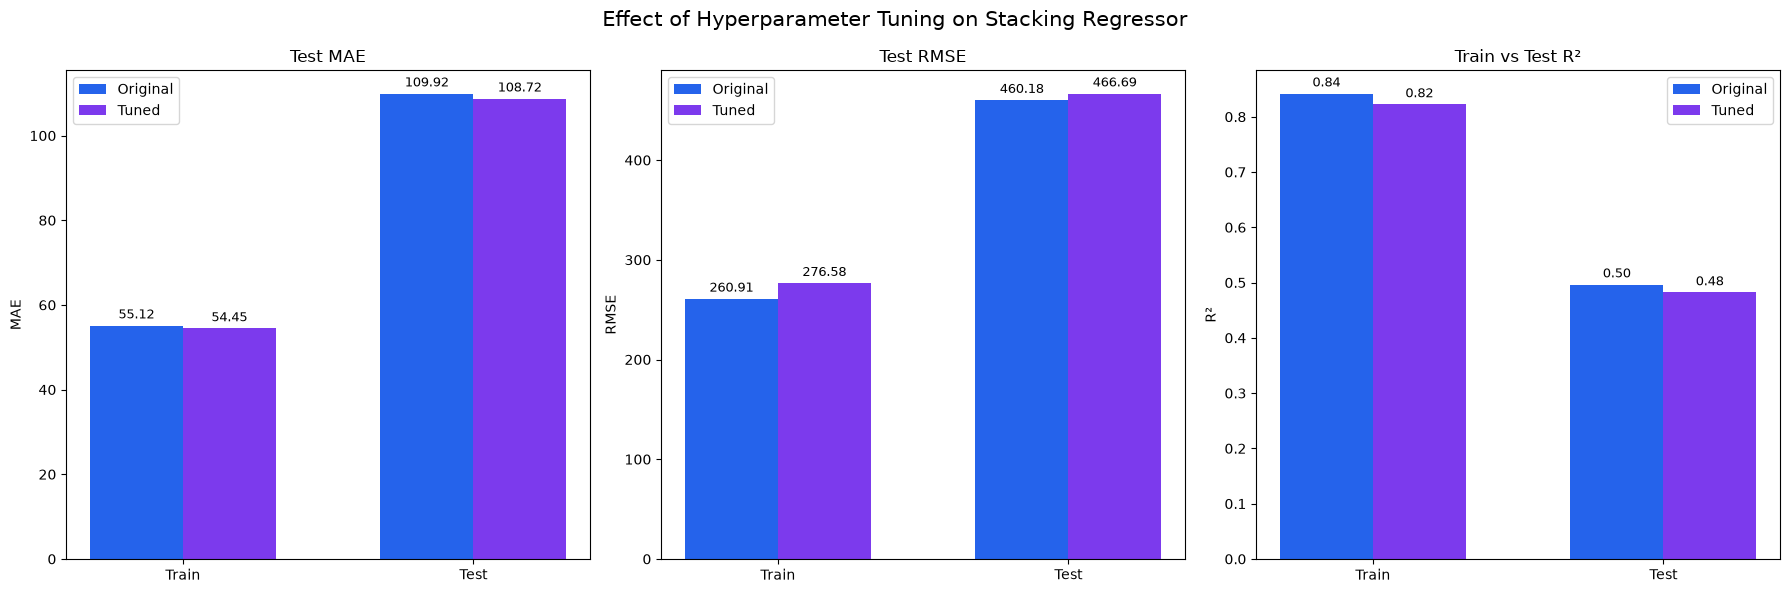

In [17]:

results = {
    "MAE": {
        "Original Train": 55.1175,
        "Original Test": 109.9215,
        "Tuned Train": 54.4465,
        "Tuned Test": 108.7197
    },
    "RMSE": {
        "Original Train": 260.9099,
        "Original Test": 460.1819,
        "Tuned Train": 276.5821,
        "Tuned Test": 466.6891
    },
    "R²": {
        "Original Train": 0.8419,
        "Original Test": 0.4964,
        "Tuned Train": 0.8223,
        "Tuned Test": 0.4821
    }
}

# ============================================
# Plot
# ============================================

evaluation = ["Train", "Test"]

x = np.arange(len(evaluation))
width = 0.32

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 6)
)

for ax, metric in zip(axes, ["MAE", "RMSE", "R²"]):

    original_values = [
        results[metric]["Original Train"],
        results[metric]["Original Test"]
    ]

    tuned_values = [
        results[metric]["Tuned Train"],
        results[metric]["Tuned Test"]
    ]

    # Original
    original_bars = ax.bar(
        x - width / 2,
        original_values,
        width,
        label="Original",
        color="#2563EB"
    )

    # Tuned
    tuned_bars = ax.bar(
        x + width / 2,
        tuned_values,
        width,
        label="Tuned",
        color="#7C3AED"
    )

    # Value labels
    ax.bar_label(
        original_bars,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

    ax.bar_label(
        tuned_bars,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

    ax.set_title(f"Test {metric}" if metric != "R²" else "Train vs Test R²")
    ax.set_ylabel(metric)

    ax.set_xticks(x)
    ax.set_xticklabels(evaluation)

    ax.legend()

plt.suptitle(
    "Effect of Hyperparameter Tuning on Stacking Regressor",
    fontsize=15
)

plt.tight_layout()
plt.show()

Hyperparameter tuning doesn't mean:

"Make the model better."

It means:

"Search for hyperparameters that perform best according to the objective you gave the tuner."

Hyperparameter tuning did not provide a consistent improvement over the baseline model. Although the tuned model achieved slightly lower MAE, it produced worse RMSE and R² on the test set. Therefore, the baseline model was retained.

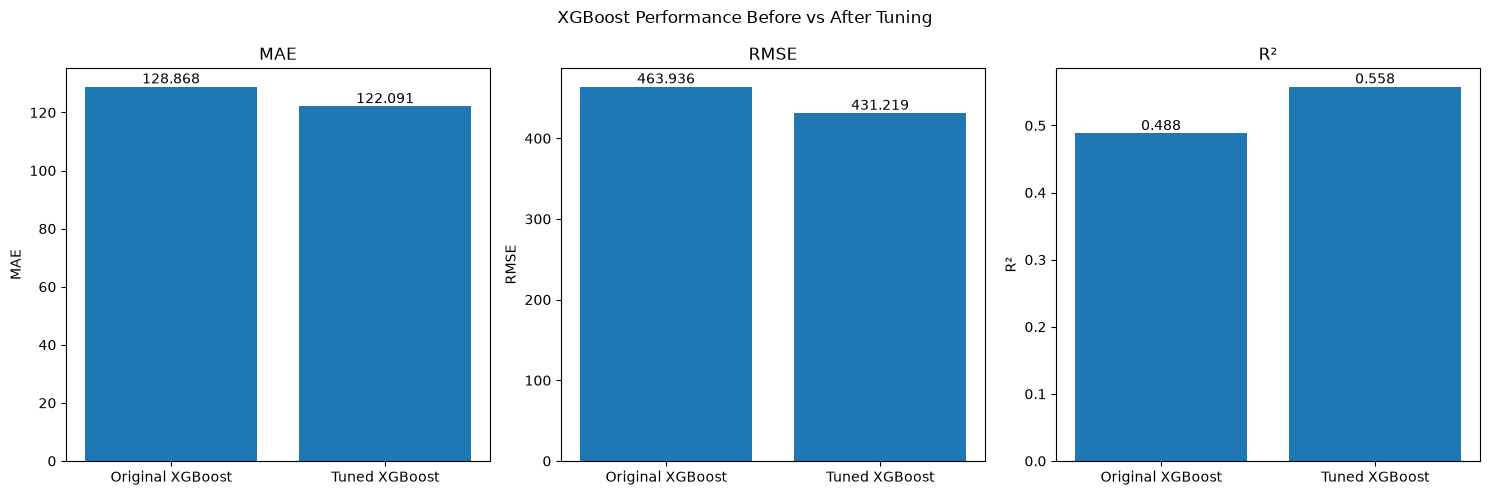

In [18]:
metrics = {
    "MAE": [128.8680, 122.0909],
    "RMSE": [463.9361, np.sqrt(185949.90698)],
    "R²": [0.4882, 0.5578]
}

models = ["Original XGBoost", "Tuned XGBoost"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (metric, values) in zip(axes, metrics.items()):

    bars = ax.bar(models, values)

    ax.set_title(metric)
    ax.set_ylabel(metric)

    # Display values
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.3f}",
            ha="center",
            va="bottom"
        )

    ax.tick_params(axis="x")

plt.suptitle("XGBoost Performance Before vs After Tuning")
plt.tight_layout()
plt.show()

                                              feature  importance
18  neighbourhood_group_cleansed_Unincorporated Areas    0.000438
15                              room_type_Shared room    0.000535
17          neighbourhood_group_cleansed_Other Cities    0.000588
14                             room_type_Private room    0.000793
13                               room_type_Hotel room    0.001301
16   neighbourhood_group_cleansed_City of Los Angeles    0.002645
11                                   instant_bookable    0.002945
0                                   host_is_superhost    0.003667
8                                                beds    0.006411
1                              neighbourhood_cleansed    0.015649
10                                   availability_365    0.022152
4                                       property_type    0.042779
9                                      minimum_nights    0.052380
12                          room_type_Entire home/apt    0.063960
5         

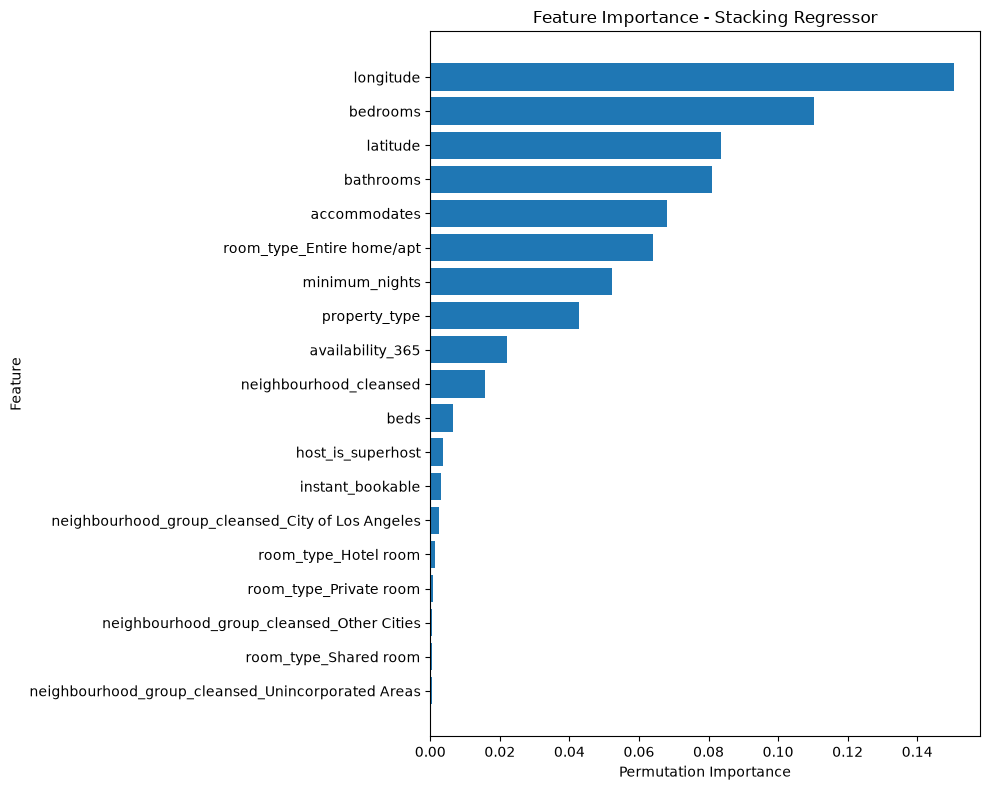

In [19]:
model = joblib.load("stacking_regressor.pkl")
y_pred = model.predict(X_test)

result = permutation_importance(
    model,
    X_test,
    y_log_test,
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
}).sort_values("importance", ascending=True)

print(feature_importance)

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Stacking Regressor")
plt.tight_layout()
plt.show()

with all these new findings in the features importance, remember to find out why it is like that: 
why beds less important than bedrooms (is it because people randomly inputs bed number)

## Testing 

For testing, remember to find a way to decode all the encoded values (create a dictionary or something)

In [20]:
model = joblib.load("stacking_regressor.pkl")

new_listing = pd.DataFrame([{
    "host_is_superhost": 0,

    "neighbourhood_cleansed": 20,
    "latitude": 34.0928,
    "longitude": -118.3287,

    "property_type": 3,
    
    "accommodates": 4,
    "bathrooms": 3.0,
    "bedrooms": 2,
    "beds": 2,

    "minimum_nights": 5,
    "availability_365": 200,
    "instant_bookable": 1,

    "room_type_Entire home/apt": 1,
    "room_type_Hotel room": 0,
    "room_type_Private room": 0,
    "room_type_Shared room": 0,

    "neighbourhood_group_cleansed_City of Los Angeles": 1,
    "neighbourhood_group_cleansed_Other Cities": 0,
    "neighbourhood_group_cleansed_Unincorporated Areas": 0,
}])

prediction = model.predict(new_listing)
prediction = np.expm1(prediction)

print("Predicted price:", prediction[0])

Predicted price: 328.03067286218266


# Ways to Improve Unseen Performance / Reduce Overfitting

## 1. Feature Engineering
- Create meaningful features from existing variables.
- Examples:
  - `price_per_person`
  - `beds_per_bedroom`
  - `bathrooms_per_person`
- Improve the information available to the model rather than just making the model more complex.

## 2. Log-Transform the Target
- Use `log1p(price)` for heavily skewed Airbnb prices.
- Convert predictions back using `expm1()`.
- Evaluate metrics on the original price scale.

## 3. Remove Noisy / High-Cardinality Features
- Investigate features such as:
  - `listing_id`
  - `host_id`
  - `name`
- These can allow the model to memorize rather than generalize.

## 4. Improve Categorical Encoding
- One-hot encoding for low-cardinality features.
- Frequency encoding or target encoding for high-cardinality features.
- Target encoding must be performed **inside CV** to avoid data leakage.

## 5. Use Cross-Validation
- Use 5-fold or similar CV.
- Compare models using **mean CV performance**, not one random split.
- Look at the standard deviation to assess stability.

## 6. Increase Regularization
For XGBoost, experiment with:
- `max_depth`
- `min_child_weight`
- `gamma`
- `subsample`
- `colsample_bytree`
- `reg_alpha`
- `reg_lambda`

**Goal:** Sacrifice some training performance if it improves unseen performance.

## 7. Use Early Stopping
- Stop adding trees when validation performance stops improving.
- Prevents unnecessary fitting of noise.

## 8. Investigate Outliers
- Don't automatically remove legitimate expensive Airbnb listings.
- Compare performance across price groups:
  - Budget
  - Mid-range
  - Luxury
- Determine whether outliers are actually harming generalization.

## 9. Check Train/Test Distribution
Compare distributions of important variables between train and test.

Look for distribution shift in:
- `price`
- `bedrooms`
- `bathrooms`
- `accommodates`
- `neighbourhood`
- `room_type`
- `property_type`

## 10. Try Different Models
Compare models rather than assuming XGBoost or stacking is best.

Examples:
- Linear Regression
- Random Forest
- XGBoost
- Gradient Boosting
- SVR

## 11. Don't Force Stacking
- Stacking is only useful if it improves CV/test performance.
- More complex ≠ better.
- Keep the simpler model if stacking does not improve generalization.